# T2 — Data Quality Analysis
Sara Milovanova & Biljana Vitanova

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent  # notebook is in notebooks/
sys.path.insert(0, str(PROJECT_ROOT))

RESULTS_FILE = Path(PROJECT_ROOT) / "results" / "t2_quality_results.json"

with open(RESULTS_FILE) as f:
    data = json.load(f)

df = pd.DataFrame(data)

ISSUE_COLS = [
    "invalid_year", "null_pickup", "null_dropoff", "placeholder_dropoff",
    "same_timestamps", "negative_duration",
    "zero_distance", "negative_distance",
    "zero_passengers", "negative_fare",
    "excessive_duration", "high_fare",
]

df["total_issues"] = df[ISSUE_COLS].sum(axis=1)
df["issue_rate_%"] = (df["total_issues"] / df["total_rows"].replace(0, pd.NA) * 100).round(2)

print(f"Loaded {len(df)} (dataset, year) records.")
df.head(10)

Loaded 83 (dataset, year) records.


,dataset,year,total_rows,invalid_year,null_pickup,null_dropoff,placeholder_dropoff,same_timestamps,negative_duration,zero_distance,negative_distance,zero_passengers,negative_fare,excessive_duration,high_fare,total_issues,issue_rate_%
0,fhv_tripdata,2015,63388532,0,0,0,63387762,0,0,0,0,0,0,85,0,63387847,100.00
1,fhv_tripdata,2016,132114083,0,0,0,132112979,0,0,0,0,0,0,28,0,132113007,100.00
2,fhv_tripdata,2017,192309557,0,0,0,72807159,0,5,0,0,0,0,58099,0,72865263,37.89
3,fhv_tripdata,2018,260874754,0,0,0,0,205,7509,0,0,0,0,87697,0,95411,0.04
4,fhv_tripdata,2019,43261276,0,0,0,0,12,66,0,0,0,0,48940,0,49018,0.11
5,fhv_tripdata,2020,14945465,0,0,0,0,0,0,0,0,0,0,11896,0,11896,0.08
6,fhv_tripdata,2021,14805265,0,0,0,0,0,0,0,0,0,0,5248,0,5248,0.04
7,fhv_tripdata,2022,14511664,0,0,0,0,0,0,0,0,0,0,2109,0,2109,0.01
8,fhv_tripdata,2023,15858639,0,0,0,0,0,1,0,0,0,0,4344,0,4345,0.03
9,fhv_tripdata,2024,17630326,0,0,0,0,0,0,0,0,0,0,3946,0,3946,0.02


## Quality checks performed

Each original parquet file is processed independently (MAP step). Issues are counted per row and aggregated by `(dataset, year)` via a Dask bag foldby reduce.

| Check | Description |
|---|---|
| `invalid_year` | Pickup year differs from the file's nominal year by more than ±1 |
| `null_pickup` | Pickup datetime is null / unparseable |
| `null_dropoff` | Dropoff datetime is null / unparseable |
| `placeholder_dropoff` | Dropoff timestamp equals the FHV sentinel value 1989-01-01 00:00:00 used as a placeholder for missing dropoff times |
| `same_timestamps` | Pickup == dropoff (zero-duration trip) |
| `negative_duration` | Dropoff earlier than pickup (excluding placeholder dropoff timestamps) |
| `zero_distance` | Trip distance == 0 (yellow, green, fhvhv only) |
| `negative_distance` | Trip distance < 0 (yellow, green, fhvhv only) |
| `zero_passengers` | Passenger count == 0 (yellow, green only) |
| `negative_fare` | Fare amount < 0 (yellow, green, fhvhv only) |
| `excessive_duration` | Trip duration > 24 hours |
| `high_fare` | Fare > $500 (yellow, green, fhvhv only) |

Columns not present in a dataset (e.g. fhv has no fare) always show 0.

In [19]:
LABELS = {
    "invalid_year": "Invalid year",
    "same_timestamps": "Zero duration",
    "negative_duration": "Negative duration",
    "zero_distance": "Zero distance",
    "negative_distance": "Negative distance",
    "zero_passengers": "Zero passengers",
    "negative_fare": "Negative fare",
    "excessive_duration": "Duration >24h",
    "high_fare": "Fare >$500",
    "placeholder_dropoff": "Placeholder dropoff"
}

---
## Yellow Tripdata

In [2]:
ds_name = "yellow_tripdata"
sub = df[df["dataset"] == ds_name].set_index("year").sort_index()

display_cols = ["total_rows"] + ISSUE_COLS + ["issue_rate_%"]
table = sub[display_cols].copy()
table["total_rows"] = table["total_rows"].map("{:,}".format)
table.index.name = "year"
print(f"{ds_name} — {len(table)} years")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
table

# summary_table = (
#     sub[["total_rows", "total_issues", "issue_rate_%"]]
#     .copy()
# )

# summary_table.columns = [
#     "Rows",
#     "Total Issues",
#     "Issue Rate (%)"
# ]

# summary_table["Rows"] = summary_table["Rows"].map("{:,}".format)
# summary_table["Total Issues"] = summary_table["Total Issues"].map("{:,}".format)

# summary_table

yellow_tripdata — 41 years


,total_rows,invalid_year,null_pickup,null_dropoff,placeholder_dropoff,same_timestamps,negative_duration,zero_distance,negative_distance,zero_passengers,negative_fare,excessive_duration,high_fare,issue_rate_%
year,,,,,,,,,,,,,,
2001,27,27,0,0,0,0,0,4,0,0,0,0,0,114.81
2002,498,498,0,0,0,0,0,84,0,0,18,139,0,148.39
2003,50,50,0,0,0,1,0,19,0,0,0,0,0,140.00
2004,1,1,0,0,0,0,0,0,0,0,0,0,0,100.00
2007,1,1,0,0,0,0,0,0,0,0,0,0,0,100.00
2008,771,771,0,0,0,4,0,42,0,0,6,0,0,106.74
2009,"170,897,359",1304,0,0,0,554459,241964,77,0,0,8,356,0,0.47
2010,"169,001,154",1,0,0,0,331942,4845,887955,2,35968,18063,141,124,0.76
2011,"176,887,272",4,0,0,0,409988,16914,1737948,0,2547627,0,100,0,2.66


---
## Green Tripdata

In [7]:
ds_name = "green_tripdata"
sub = df[df["dataset"] == ds_name].set_index("year").sort_index()

display_cols = ["total_rows"] + ISSUE_COLS + ["issue_rate_%"]
table = sub[display_cols].copy()
table["total_rows"] = table["total_rows"].map("{:,}".format)
table.index.name = "year"
print(f"{ds_name} — {len(table)} years")
table

green_tripdata — 22 years


,total_rows,invalid_year,null_pickup,null_dropoff,placeholder_dropoff,same_timestamps,negative_duration,zero_distance,negative_distance,zero_passengers,negative_fare,excessive_duration,high_fare,issue_rate_%
year,,,,,,,,,,,,,,
2008,115,115,0,0,0,1,0,22,0,0,1,0,0,120.87
2009,315,315,0,0,0,1,0,39,0,0,3,0,0,113.65
2010,348,348,0,0,0,1,0,17,0,0,1,0,0,105.46
2012,3,3,0,0,0,0,0,0,0,0,0,0,0,100.00
2014,"15,837,009",0,0,0,0,9978,202,241457,0,3346,11626,2,125,1.68
2015,"19,233,765",0,0,0,0,12831,259,273839,0,6100,30852,11,94,1.68
2016,"16,385,541",0,0,0,0,11225,101,218030,0,4375,32982,2,84,1.63
2017,"11,736,906",0,0,0,0,6640,51,135719,0,1842,26636,1,70,1.46
2018,"8,899,314",0,0,0,0,5477,28,103608,0,12371,23060,1,50,1.62


---
## FHV Tripdata

In [3]:
ds_name = "fhv_tripdata"
sub = df[df["dataset"] == ds_name].set_index("year").sort_index()

display_cols = ["total_rows"] + ISSUE_COLS + ["issue_rate_%"]
table = sub[display_cols].copy()
table["total_rows"] = table["total_rows"].map("{:,}".format)
table.index.name = "year"
print(f"{ds_name} — {len(table)} years")
table

fhv_tripdata — 12 years


,total_rows,invalid_year,null_pickup,null_dropoff,placeholder_dropoff,same_timestamps,negative_duration,zero_distance,negative_distance,zero_passengers,negative_fare,excessive_duration,high_fare,issue_rate_%
year,,,,,,,,,,,,,,
2015,"63,388,532",0,0,0,63387762,0,0,0,0,0,0,85,0,100.00
2016,"132,114,083",0,0,0,132112979,0,0,0,0,0,0,28,0,100.00
2017,"192,309,557",0,0,0,72807159,0,5,0,0,0,0,58099,0,37.89
2018,"260,874,754",0,0,0,0,205,7509,0,0,0,0,87697,0,0.04
2019,"43,261,276",0,0,0,0,12,66,0,0,0,0,48940,0,0.11
2020,"14,945,465",0,0,0,0,0,0,0,0,0,0,11896,0,0.08
2021,"14,805,265",0,0,0,0,0,0,0,0,0,0,5248,0,0.04
2022,"14,511,664",0,0,0,0,0,0,0,0,0,0,2109,0,0.01
2023,"15,858,639",0,0,0,0,0,1,0,0,0,0,4344,0,0.03


### FHV-specific data quality note

The FHV dataset contains a schema inconsistency in older years. Many records use `1989-01-01 00:00:00` as a placeholder value in `dropOff_datetime` rather than a true dropoff timestamp.

Without special handling these records would appear as trips with negative durations because the placeholder date predates the pickup timestamp by decades.

A dedicated `placeholder_dropoff` quality metric was therefore introduced. Placeholder records are counted as a data quality issue but are excluded from duration-based checks (`negative_duration` and `excessive_duration`) to avoid double-counting.

---
## FHVHV Tripdata

In [9]:
ds_name = "fhvhv_tripdata"
sub = df[df["dataset"] == ds_name].set_index("year").sort_index()

display_cols = ["total_rows"] + ISSUE_COLS + ["issue_rate_%"]
table = sub[display_cols].copy()
table["total_rows"] = table["total_rows"].map("{:,}".format)
table.index.name = "year"
print(f"{ds_name} — {len(table)} years")
table

fhvhv_tripdata — 8 years


,total_rows,invalid_year,null_pickup,null_dropoff,placeholder_dropoff,same_timestamps,negative_duration,zero_distance,negative_distance,zero_passengers,negative_fare,excessive_duration,high_fare,issue_rate_%
year,,,,,,,,,,,,,,
2019,"234,630,264",0,0,0,0,1804,7926,514155,0,0,594752,0,2173,0.48
2020,"143,309,871",0,0,0,0,452,7444,152429,0,0,165773,0,1262,0.23
2021,"174,596,652",0,0,0,0,613,7558,53147,0,0,200924,65,2403,0.15
2022,"212,416,083",0,0,0,0,10,8569,43445,0,0,233608,6,4066,0.14
2023,"232,490,020",0,0,0,0,26,8481,40779,0,0,68532,1,4450,0.05
2024,"239,470,448",0,0,0,0,27,9653,34059,0,0,18233,0,5002,0.03
2025,"243,589,684",0,0,0,0,27,12204,28128,0,0,13495,0,6298,0.02
2026,"40,816,059",0,0,0,0,1,0,4802,0,0,34110,0,1017,0.10


---
## Overall Summary — All Datasets

In [11]:
summary = (
    df.groupby("dataset")[["total_rows", "total_issues"] + ISSUE_COLS]
    .sum()
    .assign(issue_rate_pct=lambda x: (x["total_issues"] / x["total_rows"] * 100).round(2))
)

display_summary = summary.copy()
display_summary["total_rows"]   = display_summary["total_rows"].map("{:,}".format)
display_summary["total_issues"] = display_summary["total_issues"].map("{:,}".format)

print("Aggregate quality summary across all years per dataset:")
display_summary

Aggregate quality summary across all years per dataset:


,total_rows,total_issues,invalid_year,null_pickup,null_dropoff,placeholder_dropoff,same_timestamps,negative_duration,zero_distance,negative_distance,zero_passengers,negative_fare,excessive_duration,high_fare,issue_rate_pct
dataset,,,,,,,,,,,,,,,
fhv_tripdata,"798,450,799","268,550,042",0,0,0,268307900,261,7874,0,0,0,0,234007,0,33.63
fhvhv_tripdata,"1,521,319,081","2,291,909",0,0,0,0,2960,61835,870944,0,0,1329427,72,26671,0.15
green_tripdata,"84,153,708","1,688,420",789,0,0,0,67895,2387,1366846,19527,70189,160063,85,639,2.01
yellow_tripdata,"1,834,085,397","32,939,207",2718,0,0,0,3831449,372275,14013628,11446,9746697,4953134,3249,4611,1.80


,Total rows,Inv. Year,Same TS,Neg. Dur.,Zero Dist.,Neg. Dist.,Zero Pax,Neg. Fare,Exc. Dur.,High Fare,Total issues,Rate (%)
Year,,,,,,,,,,,,
2009,"170,897,359","1,304","554,459","241,964",77,—,—,8,356,—,"798,168",0.47%
2010,"169,001,154",1,"331,942","4,845","887,955",2,"35,968","18,063",141,124,"1,279,041",0.76%
2011,"176,887,272",4,"409,988","16,914","1,737,948",—,"2,547,627",—,100,—,"4,712,581",2.66%
2012,"171,359,008",1,"385,642","1,292","958,564",—,"1,242,327",—,53,—,"2,587,879",1.51%
2013,"171,816,340",—,"494,450","10,996","1,119,568",—,"4,938","3,080",173,62,"1,633,267",0.95%
2014,"165,447,580",1,"356,083","8,907","954,350",1,"7,995","18,523",210,141,"1,346,211",0.81%
2015,"146,039,232",1,"171,080","3,917","876,727",3,"40,683","51,339",480,382,"1,144,612",0.78%
2016,"131,131,805",—,"141,290","2,180","773,693",—,"13,431","55,661",184,404,"986,843",0.75%
2017,"113,500,386",—,"107,007","1,447","743,181",—,"166,087","56,091",11,339,"1,074,163",0.95%


  Saved t2_figures\t2_yellow_tripdata_chart.png
  Saved t2_figures\t2_yellow_tripdata_chart.pdf


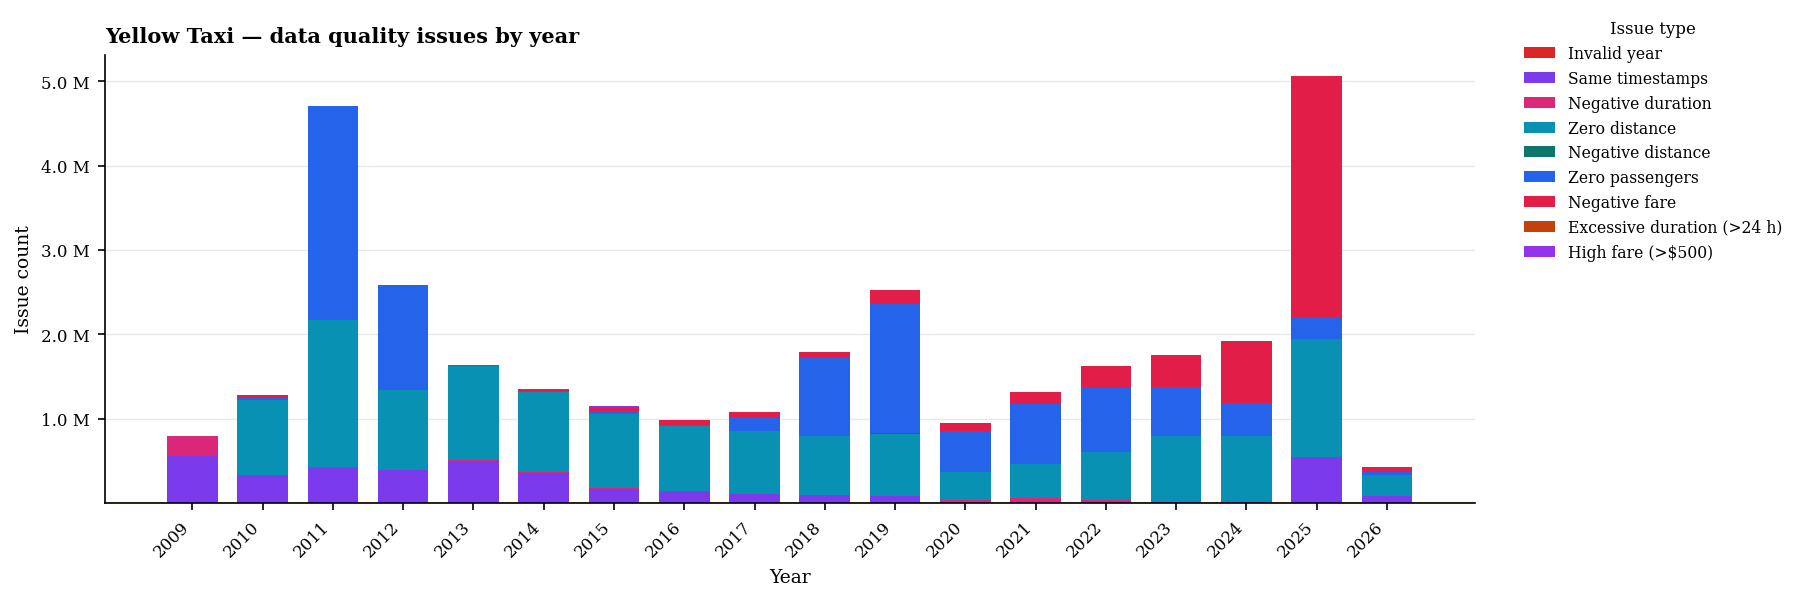

,Total rows,Inv. Year,Same TS,Neg. Dur.,Zero Dist.,Neg. Dist.,Zero Pax,Neg. Fare,Exc. Dur.,High Fare,Total issues,Rate (%)
Year,,,,,,,,,,,,
2014,"15,837,009",—,"9,978",202,"241,457",—,"3,346","11,626",2,125,"266,736",1.68%
2015,"19,233,765",—,"12,831",259,"273,839",—,"6,100","30,852",11,94,"323,986",1.68%
2016,"16,385,541",—,"11,225",101,"218,030",—,"4,375","32,982",2,84,"266,799",1.63%
2017,"11,736,906",—,"6,640",51,"135,719",—,"1,842","26,636",1,70,"170,959",1.46%
2018,"8,899,314",—,"5,477",28,"103,608",—,"12,371","23,060",1,50,"144,595",1.62%
2019,"6,300,814",—,"14,270",302,"138,590","18,705","11,688","19,906",65,93,"203,619",3.23%
2020,"1,734,166",2,"2,448",94,"64,464",822,"3,199","4,422",1,7,"75,459",4.35%
2021,"1,068,729",—,"1,212",2,"40,486",—,"1,431","2,090",—,10,"45,231",4.23%
2022,"840,394",—,"1,500",1,"49,391",—,"3,517","2,163",—,13,"56,585",6.73%


  Saved t2_figures\t2_green_tripdata_chart.png
  Saved t2_figures\t2_green_tripdata_chart.pdf


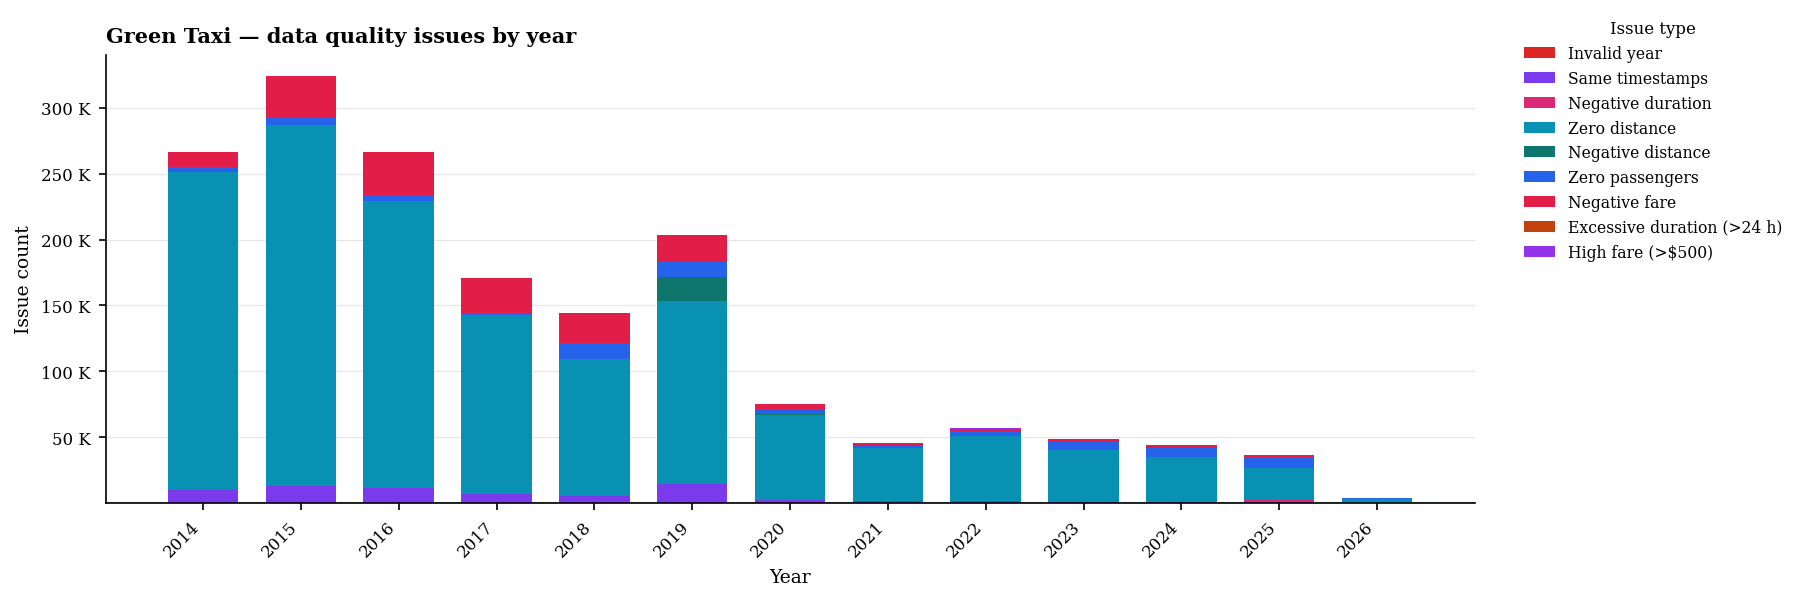

,Total rows,Plchldr DO,Same TS,Neg. Dur.,Exc. Dur.,Total issues,Rate (%)
Year,,,,,,,
2015,"63,388,532","63,387,762",—,—,85,"63,387,847",100.00%
2016,"132,114,083","132,112,979",—,—,28,"132,113,007",100.00%
2017,"192,309,557","72,807,159",—,5,"58,099","72,865,263",37.89%
2018,"260,874,754",—,205,"7,509","87,697","95,411",0.04%
2019,"43,261,276",—,12,66,"48,940","49,018",0.11%
2020,"14,945,465",—,—,—,"11,896","11,896",0.08%
2021,"14,805,265",—,—,—,"5,248","5,248",0.04%
2022,"14,511,664",—,—,—,"2,109","2,109",0.01%
2023,"15,858,639",—,—,1,"4,344","4,345",0.03%


d:\Projects\bd\Project\big-data-project\src\t2_quality_plots.py:289: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


  Saved t2_figures\t2_fhv_tripdata_chart.png
  Saved t2_figures\t2_fhv_tripdata_chart.pdf


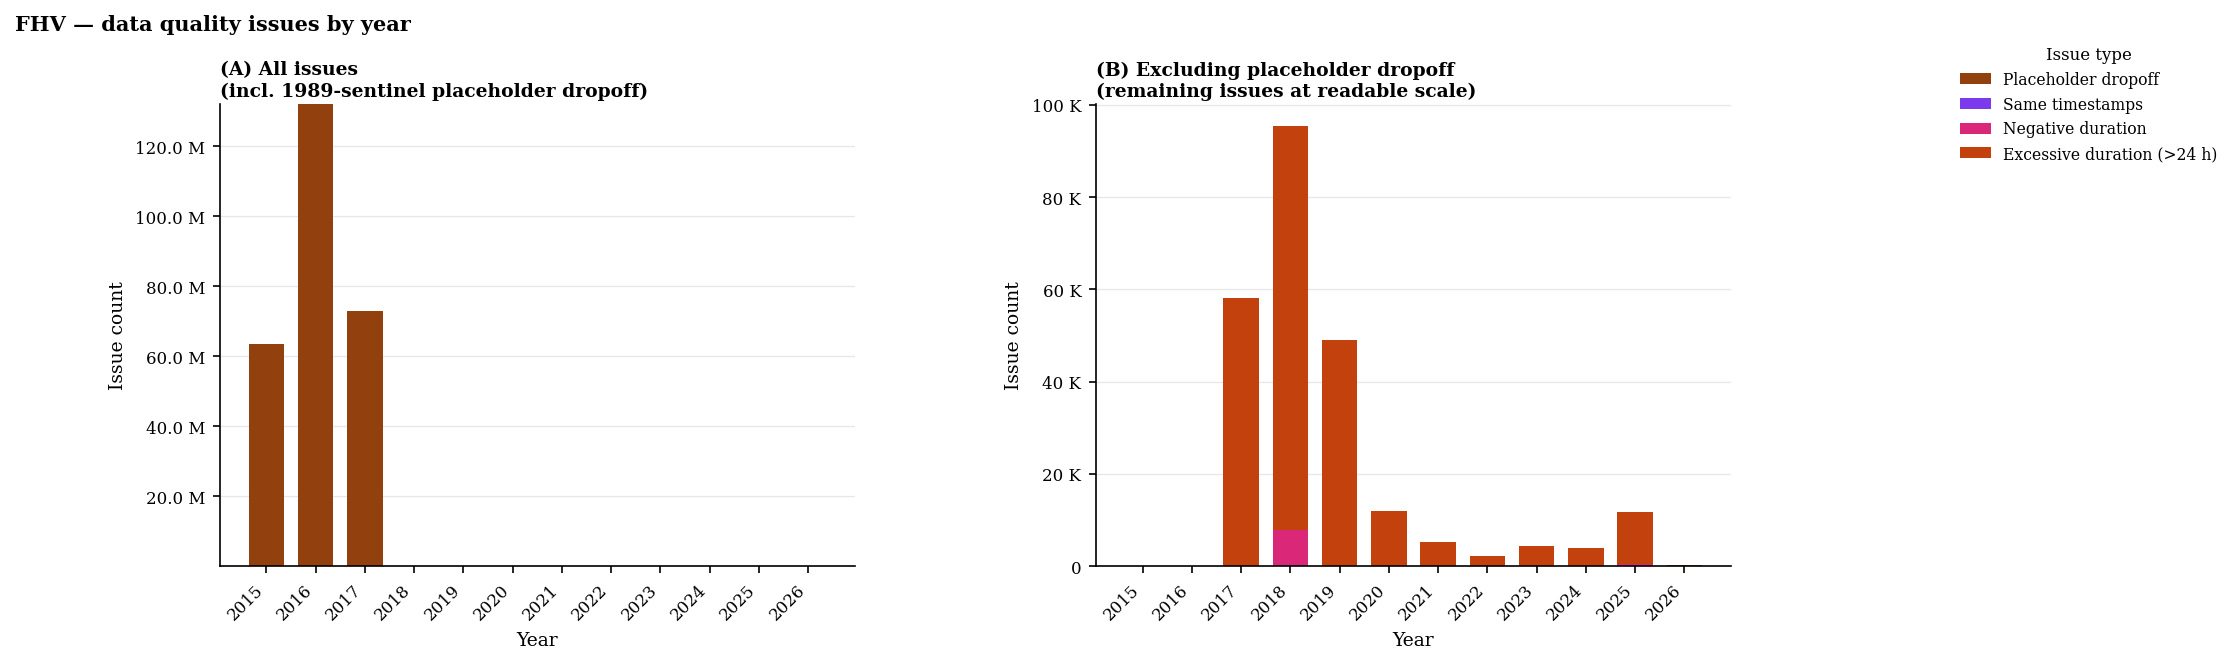

,Total rows,Same TS,Neg. Dur.,Zero Dist.,Neg. Fare,Exc. Dur.,High Fare,Total issues,Rate (%)
Year,,,,,,,,,
2019,"234,630,264","1,804","7,926","514,155","594,752",—,"2,173","1,120,810",0.48%
2020,"143,309,871",452,"7,444","152,429","165,773",—,"1,262","327,360",0.23%
2021,"174,596,652",613,"7,558","53,147","200,924",65,"2,403","264,710",0.15%
2022,"212,416,083",10,"8,569","43,445","233,608",6,"4,066","289,704",0.14%
2023,"232,490,020",26,"8,481","40,779","68,532",1,"4,450","122,269",0.05%
2024,"239,470,448",27,"9,653","34,059","18,233",—,"5,002","66,974",0.03%
2025,"243,589,684",27,"12,204","28,128","13,495",—,"6,298","60,152",0.02%
2026,"40,816,059",1,—,"4,802","34,110",—,"1,017","39,930",0.10%


  Saved t2_figures\t2_fhvhv_tripdata_chart.png
  Saved t2_figures\t2_fhvhv_tripdata_chart.pdf


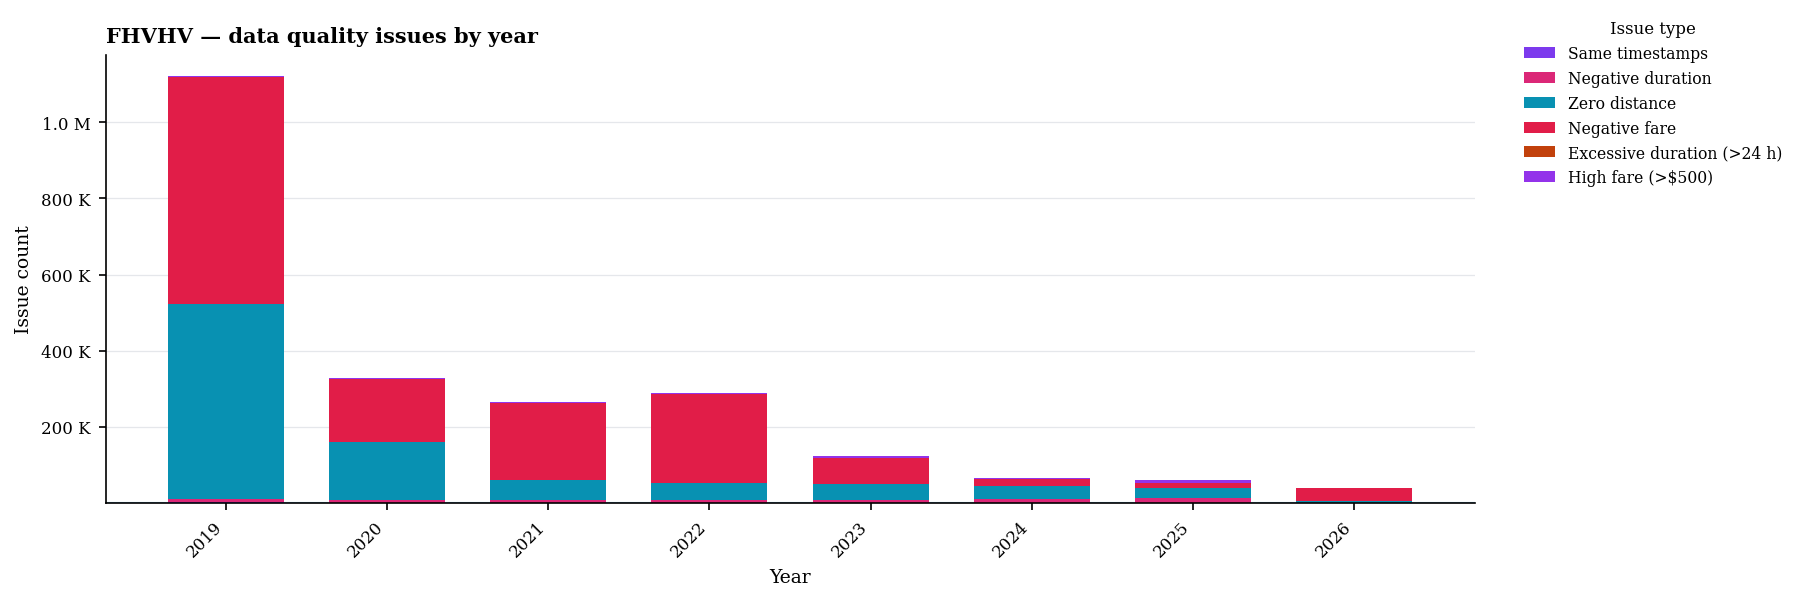

  Saved t2_figures\t2_yellow_tripdata_table.png
  Saved t2_figures\t2_yellow_tripdata_table.pdf


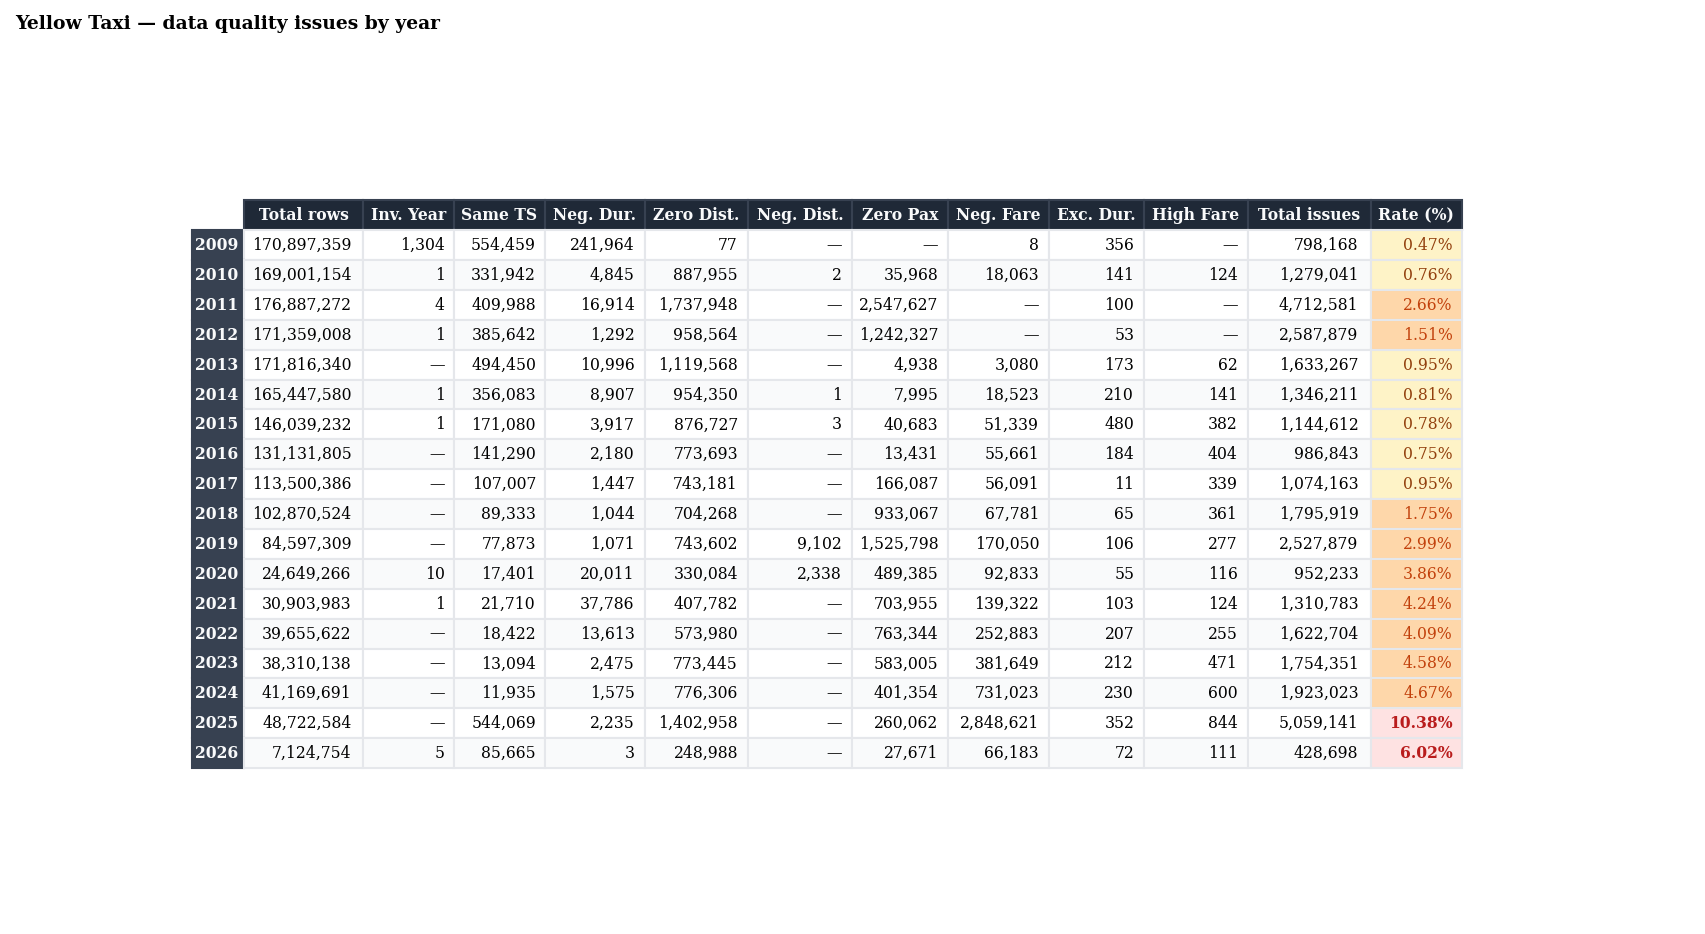

  Saved LaTeX table: t2_figures\t2_yellow_tripdata_table.tex
  Saved t2_figures\t2_overview_grid.png
  Saved t2_figures\t2_overview_grid.pdf


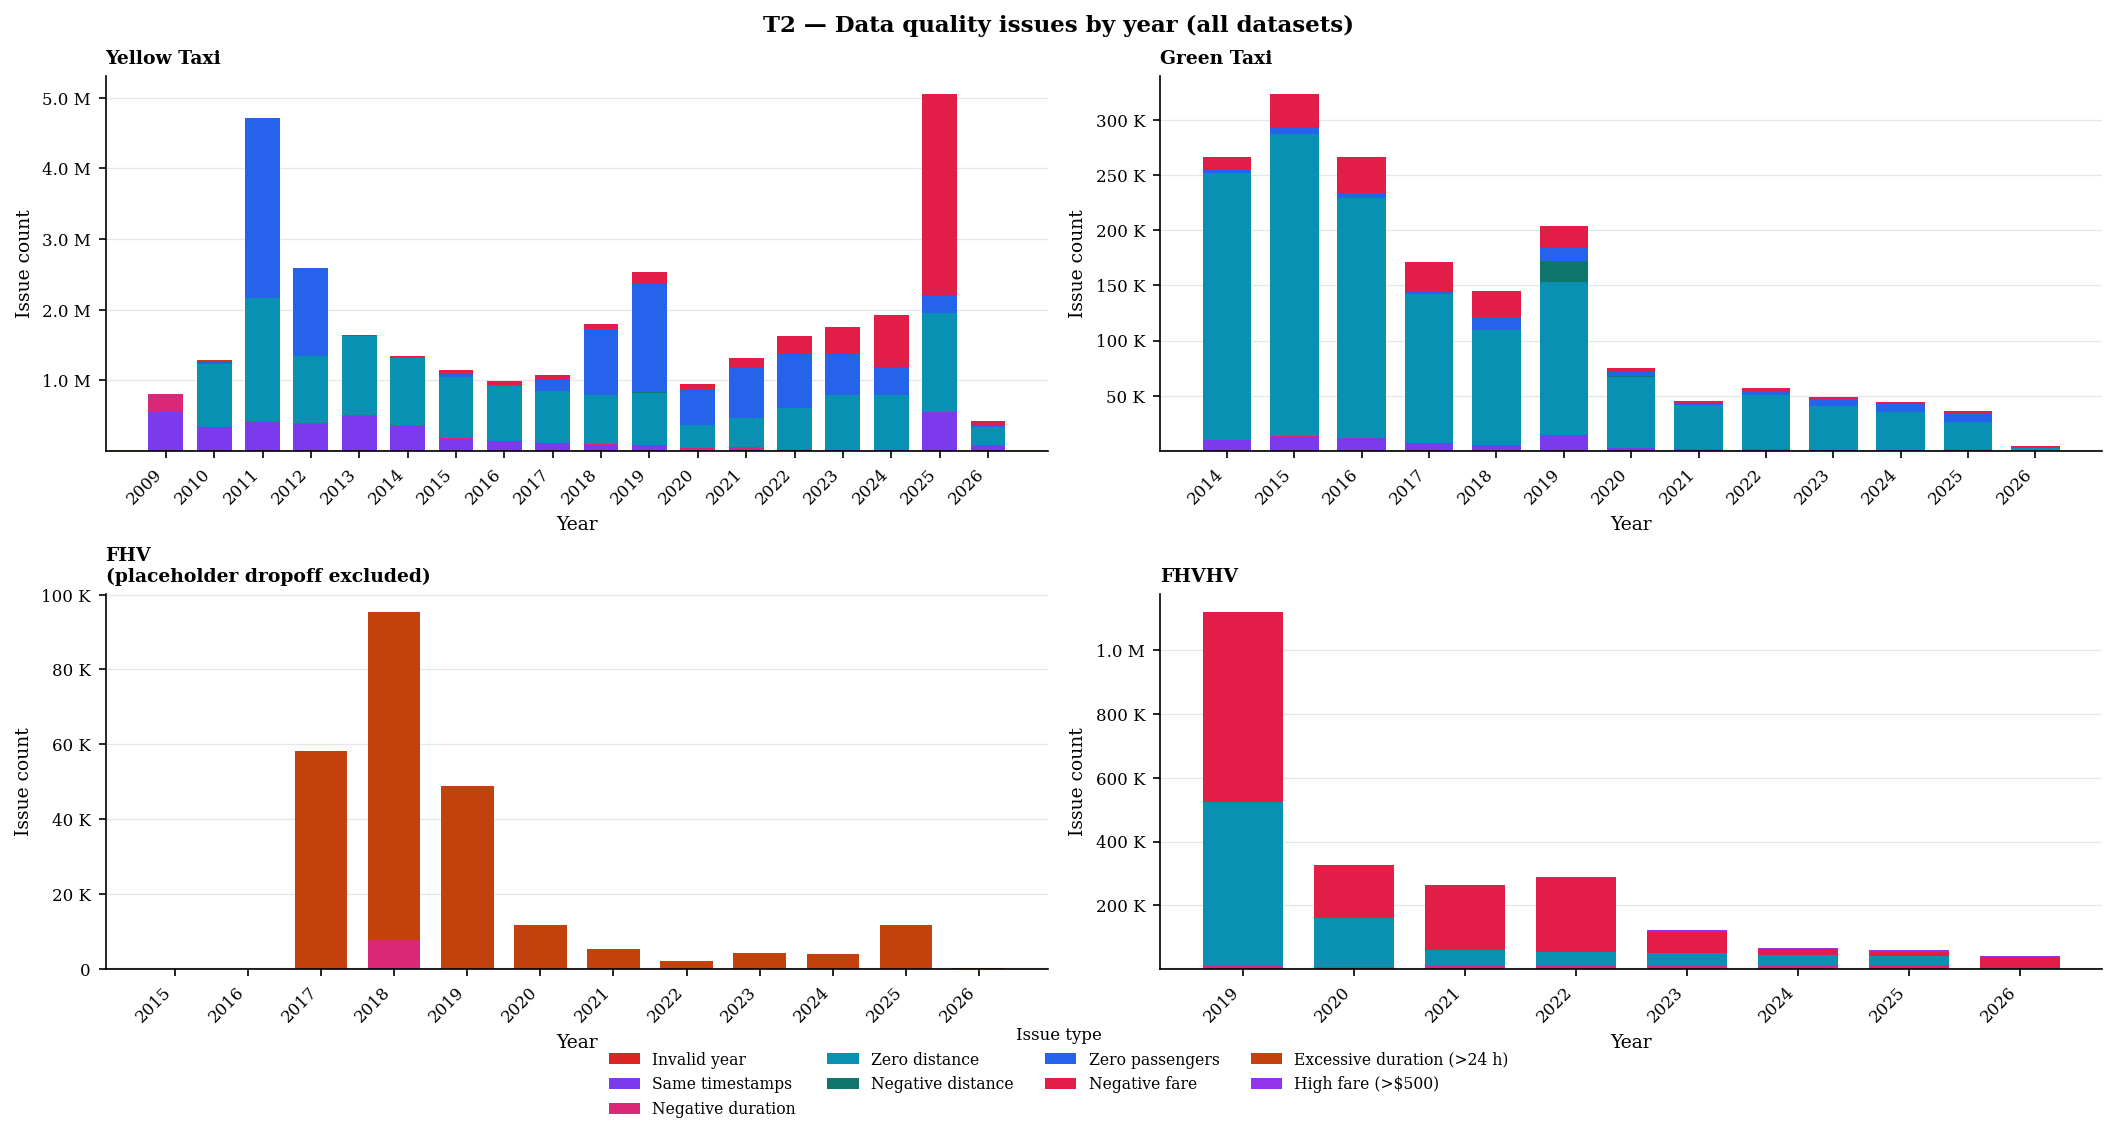

In [11]:
from src.t2_quality_plots import (
    load_data,
    plot_quality_chart,
    make_quality_table,
    render_table_figure,
    DS_CONFIG,
    export_latex_table,
    plot_overview_grid,
)
from IPython.display import display

df = load_data(RESULTS_FILE)

for ds in DS_CONFIG:
    display(make_quality_table(df, ds))
    plot_quality_chart(df, ds)

# optional extras
render_table_figure(df, "yellow_tripdata")   # saves PNG + PDF
export_latex_table(df, "yellow_tripdata")    # saves .tex
plot_overview_grid(df)                       # 2×2 summary